In [8]:
import pandas as pd
import os

# Load the dataset using the relative path from the code directory
data_path = os.path.join('..', 'data', 'predictive_maintenance.csv')
df = pd.read_csv(data_path)

# Preview the shape and columns to confirm it loaded perfectly
print(f"Dataset Loaded Successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset Loaded Successfully! Rows: 10000, Columns: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Class distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


C:\Users\Utsav Singh\AppData\Local\Temp\ipykernel_27460\1231738499.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, palette='viridis')


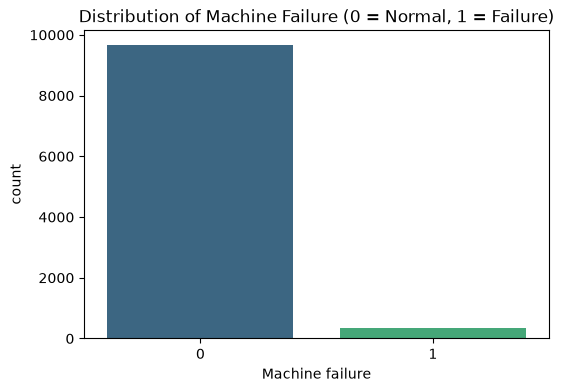

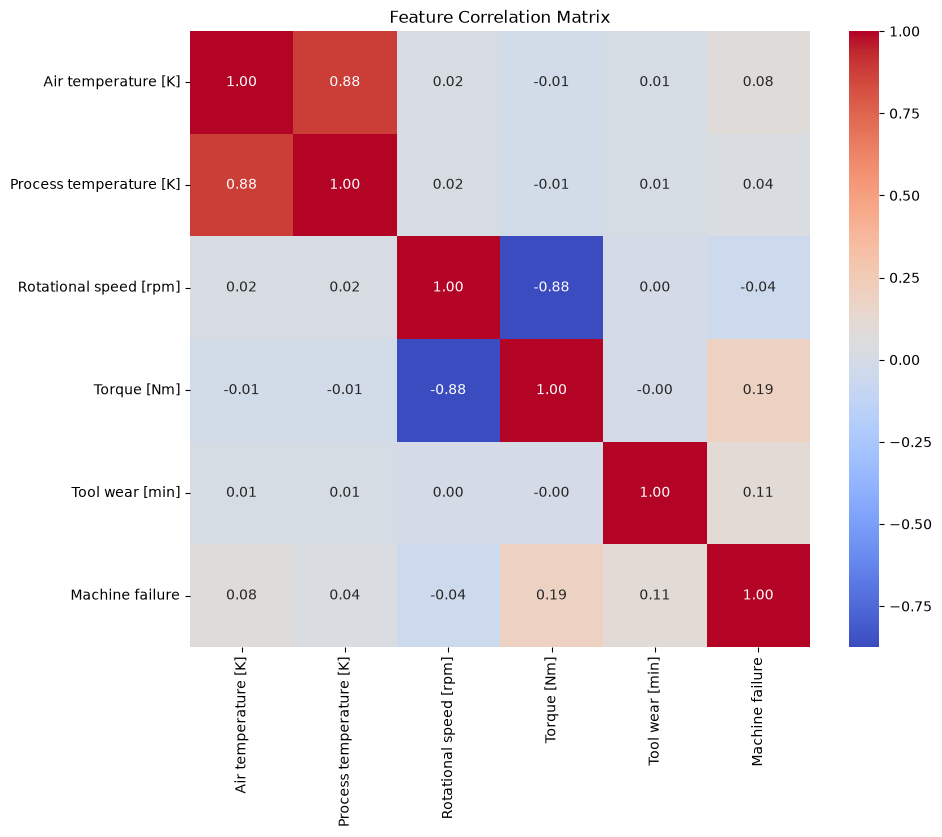

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the distribution of our target variable
print("Class distribution:")
print(df['Machine failure'].value_counts())

# Visualize the class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df, palette='viridis')
plt.title('Distribution of Machine Failure (0 = Normal, 1 = Failure)')
plt.show()

# Visualize correlations between numerical features (excluding IDs and specific failure modes)
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df = numerical_df.drop(['UDI', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)

sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Encode the categorical 'Type' column (L, M, H) into numbers
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# 2. Separate features (X) and the target label (y)
columns_to_drop = ['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = df.drop(columns_to_drop, axis=1)
y = df['Machine failure']

# 3. Split into training (80%) and testing (20%) sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale the features so columns with big numbers don't overpower the rest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (8000, 6)
Testing features shape: (2000, 6)


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier with balanced class weights
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.74      0.74        68

    accuracy                           0.98      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.98      0.98      0.98      2000



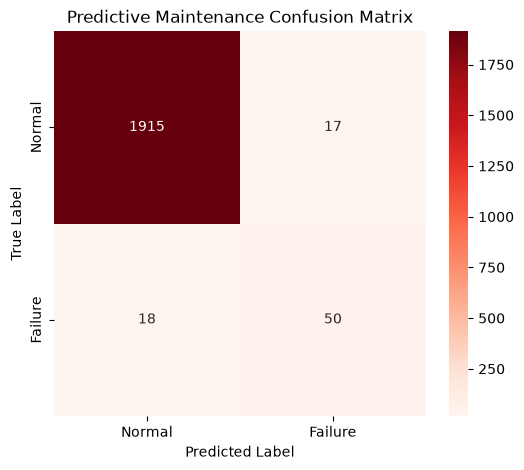

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)

# Print out Precision, Recall, and F1-Score
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix to see exactly where the model succeeded or missed
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('Predictive Maintenance Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

C:\Users\Utsav Singh\AppData\Local\Temp\ipykernel_27460\3470882296.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='mako')


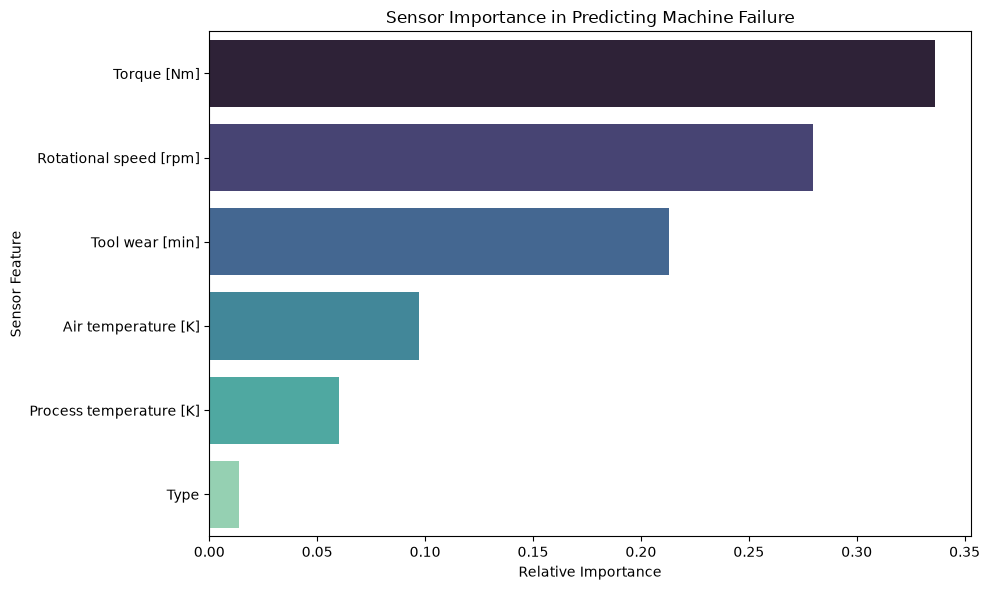

In [14]:
import numpy as np

# Extract feature importances from the trained model
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='mako')
plt.title('Sensor Importance in Predicting Machine Failure')
plt.xlabel('Relative Importance')
plt.ylabel('Sensor Feature')
plt.tight_layout()
plt.show()

In [15]:

import joblib
import os

# Create a directory for saved models if it doesn't exist
os.makedirs(os.path.join('..', 'models'), exist_ok=True)

# Define file paths
model_path = os.path.join('..', 'models', 'predictive_maintenance_rf.joblib')
scaler_path = os.path.join('..', 'models', 'scaler.joblib')

# Save the Random Forest model and the Scaler
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model successfully saved to: {model_path}")
print(f"Scaler successfully saved to: {scaler_path}")

Model successfully saved to: ..\models\predictive_maintenance_rf.joblib
Scaler successfully saved to: ..\models\scaler.joblib
